In [1]:
import sys
print(sys.executable)
print(sys.version)


C:\Users\Admin\anaconda3\envs\Ease\python.exe
3.11.13 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 13:03:15) [MSC v.1929 64 bit (AMD64)]


In [2]:
!pip install factor-analyzer


In [3]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from factor_analyzer.factor_analyzer import calculate_kmo

In [4]:
economic_data = pd.read_csv("Economic_data.csv")

In [5]:
import pandas as pd 
import miceforest as mf
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv("Economic_data.csv")

data_for_imputation = data.drop(['Country', 'Year'], axis=1)

kernel = mf.ImputationKernel(
    data_for_imputation,
    num_datasets = 1,
    mean_match_candidates=0,
    random_state = 28
    )

kernel.mice(30)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv('imputed_economic_data_mice.csv', index=False)

df = pd.read_csv("imputed_economic_data_mice.csv")

In [7]:
!pip install plotnine

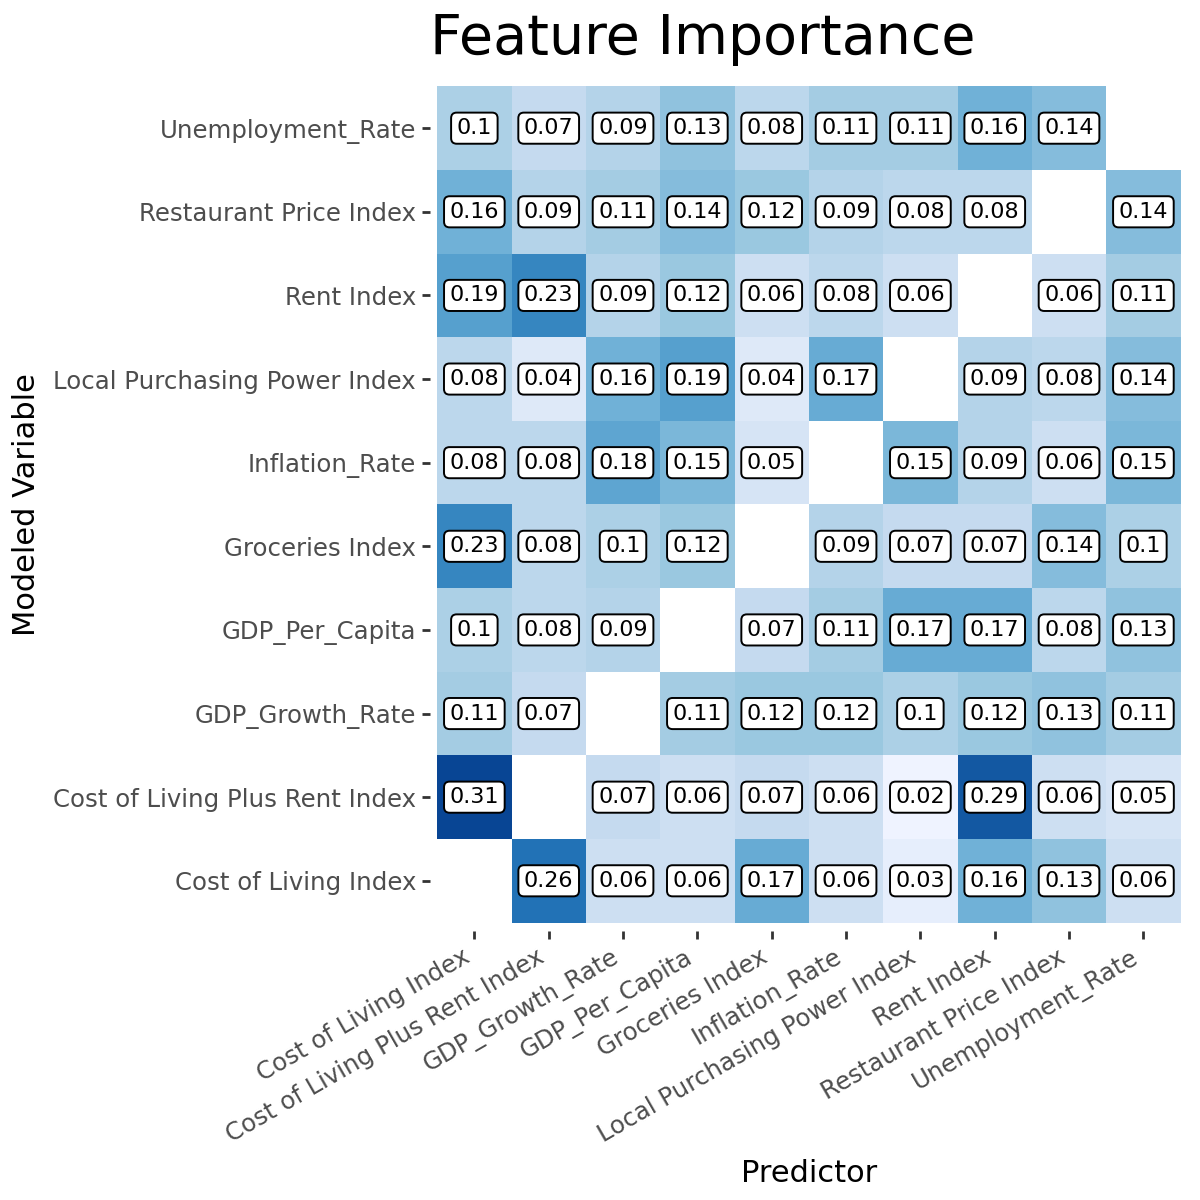

In [8]:
kernel.plot_feature_importance(dataset=0)

In [9]:
k=kernel.plot_imputed_distributions()
k.save(filename='KDE.png',width=10,height=5)

C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 10 x 5 in image.
C:\Users\Admin\anaconda3\envs\Ease\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: KDE.png


In [10]:
optimal_params = kernel.tune_parameters(
    dataset=0, 
    use_gbdt=True,
    num_iterations=500,
    random_state=1,
)
kernel.mice(1, variable_parameters=optimal_params)
pd.DataFrame(optimal_params)



,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Unemployment_Rate,Inflation_Rate,GDP_Growth_Rate,GDP_Per_Capita
boosting,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt,gbdt
data_sample_strategy,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging,bagging
num_iterations,499,500,407,500,499,500,500,107,500,499
max_depth,4,4,4,5,3,4,5,5,5,3
num_leaves,12,17,11,18,18,15,6,16,15,11
min_data_in_leaf,3,5,1,1,34,6,109,19,4,11
min_sum_hessian_in_leaf,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
min_gain_to_split,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bagging_fraction,0.580973,0.501521,0.582307,0.779917,0.484219,0.989755,0.572203,0.537392,0.809136,0.659727
feature_fraction_bynode,0.922566,0.299912,0.697415,0.778489,0.776686,0.621771,0.932327,0.643879,0.650828,0.487223


In [11]:
kernel.mice(30,variable_parameters=optimal_params)
imputed_data = kernel.complete_data(0)

imputed_data['Country'] = data['Country']
imputed_data['Year'] = data['Year']

imputed_data.to_csv('Testing_imputation.csv', index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



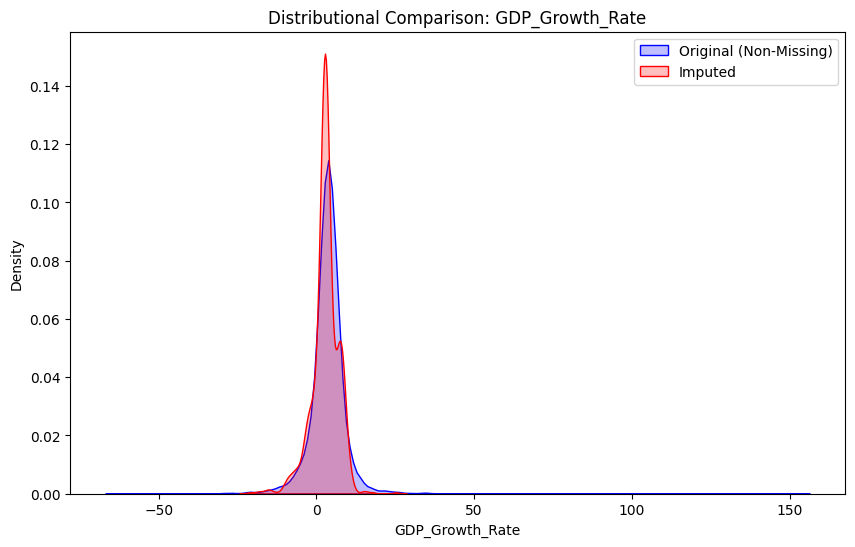

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



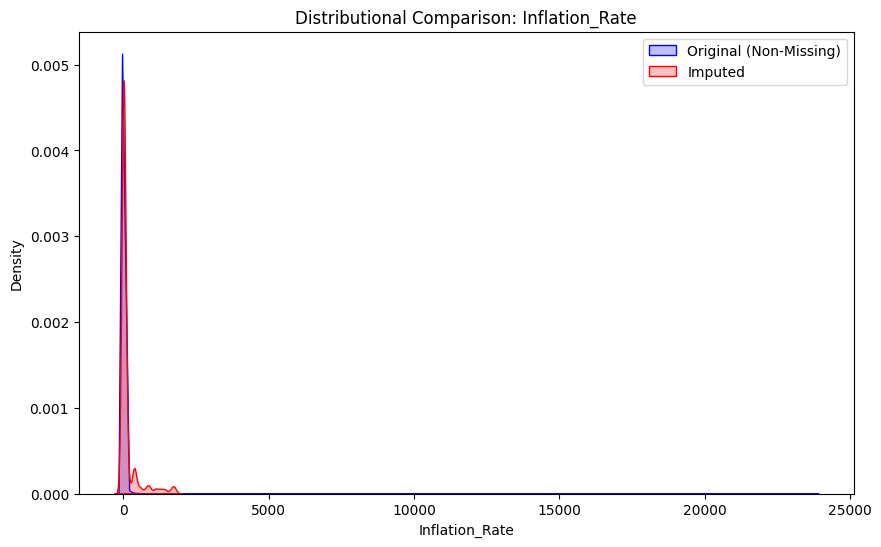

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



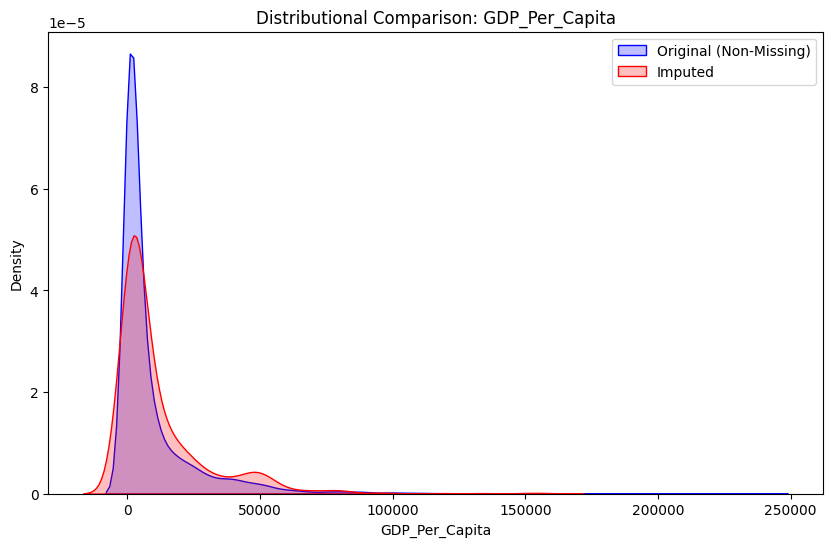

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



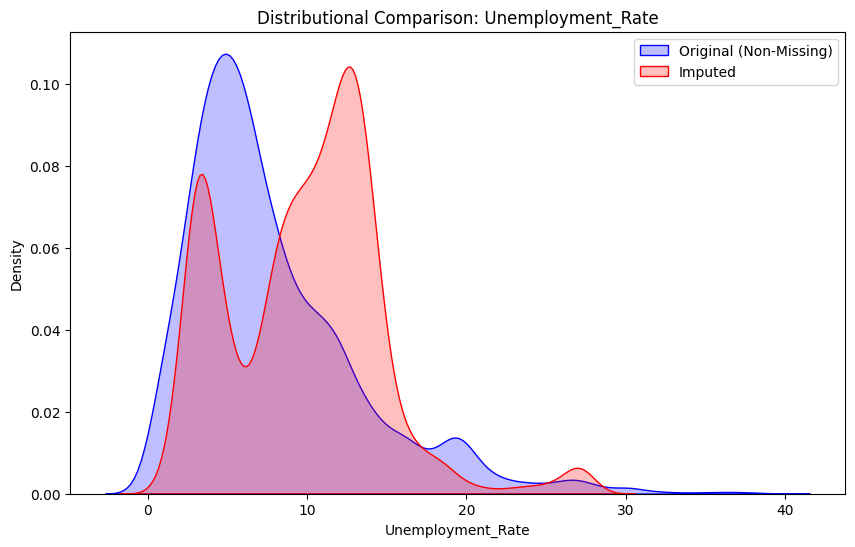

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



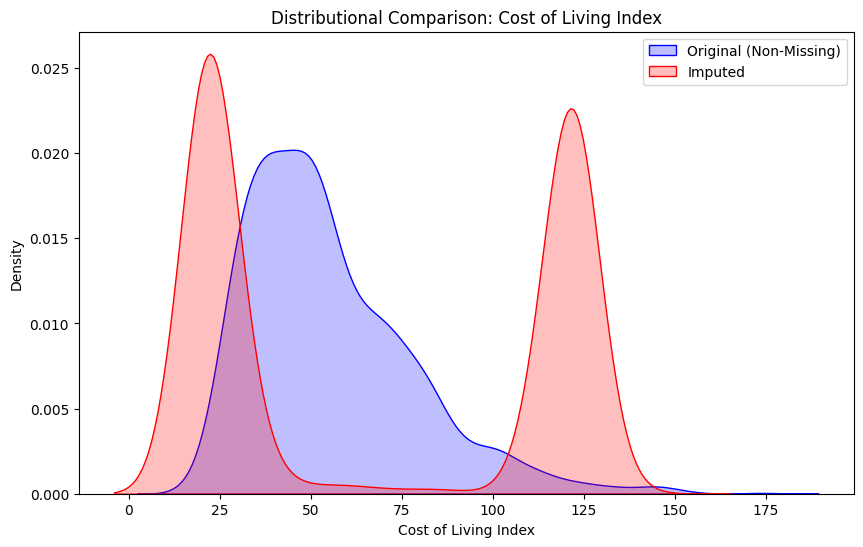

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



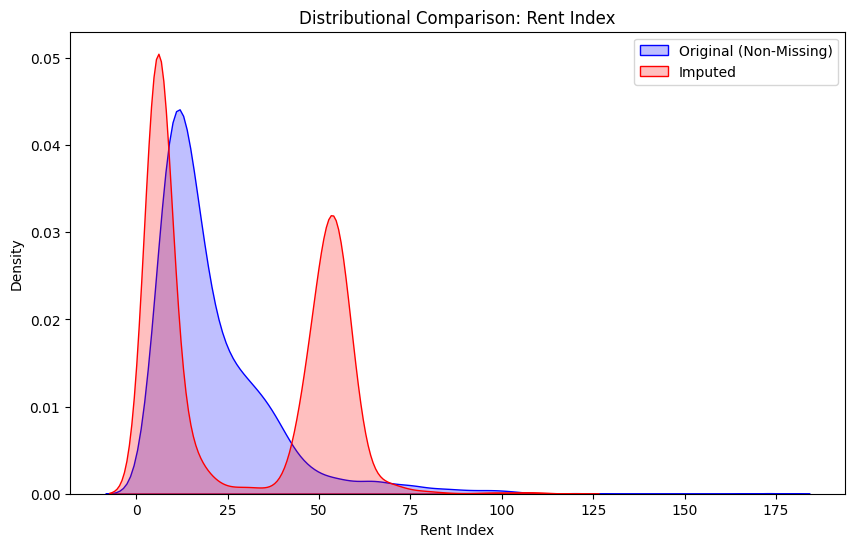

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



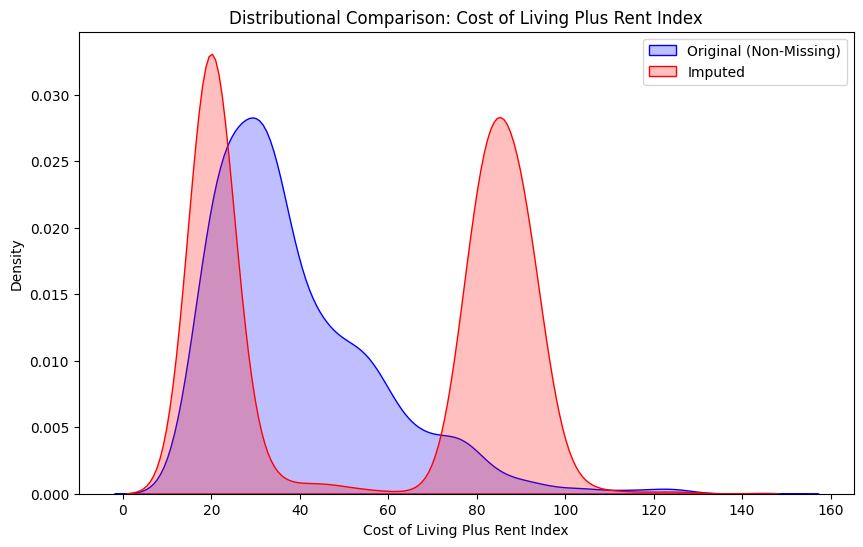

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



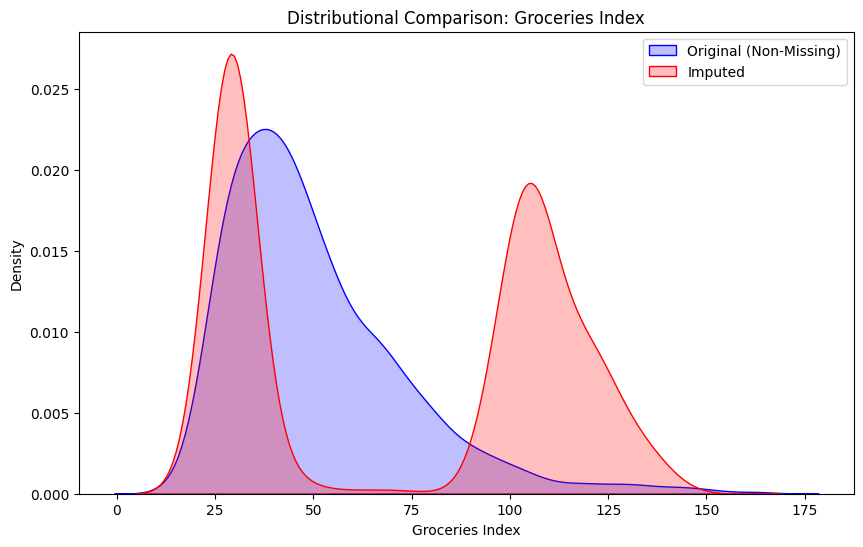

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



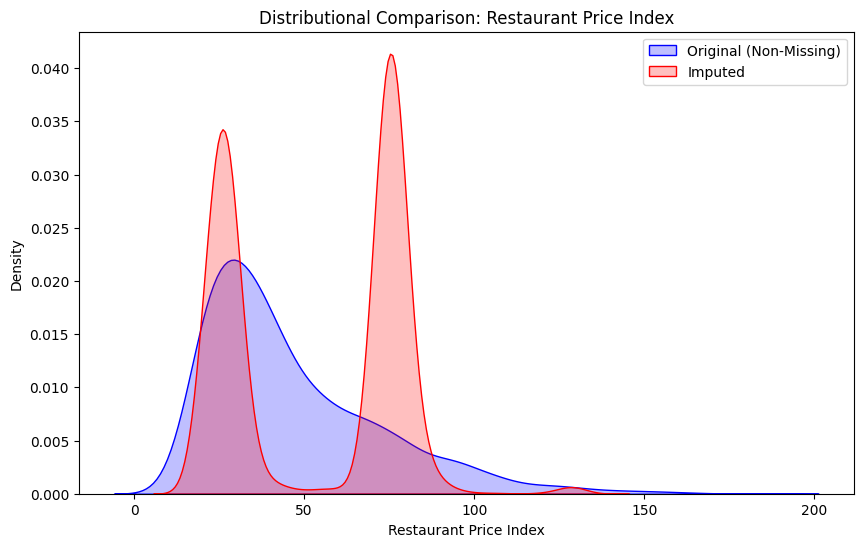

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1007290577.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.



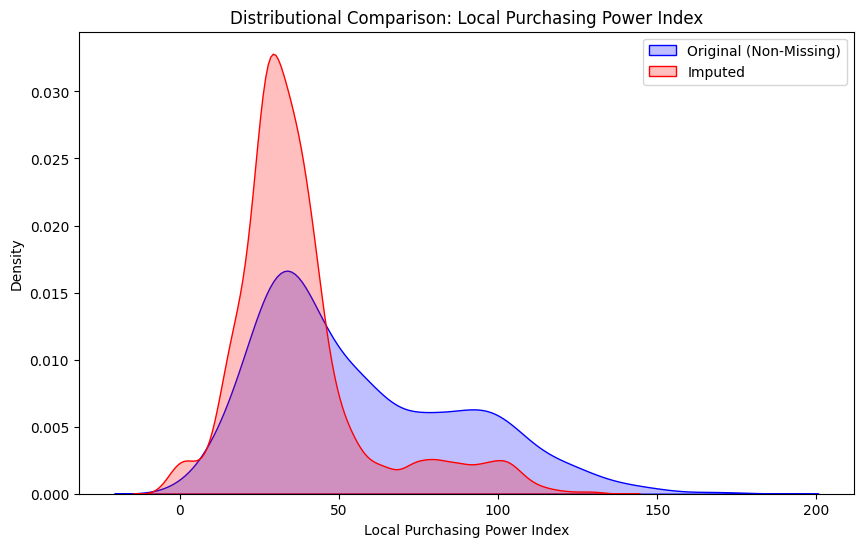

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

original_data = pd.read_csv("Economic_data.csv")

original_data_clean = original_data.drop(['Country', 'Year'], axis=1)
imputed_data_clean = imputed_data.drop(['Country', 'Year'], axis=1)

def plot_distributions(original, imputed, column_name):
    plt.figure(figsize=(10, 6))

    sns.kdeplot(original.dropna(), label="Original (Non-Missing)", color='blue', shade=True)
    missing_indices = original[original.isna()].index
    sns.kdeplot(imputed.loc[missing_indices], label="Imputed", color='red', shade=True)
    
    plt.title(f'Distributional Comparison: {column_name}')
    plt.legend()
    plt.show()


for column in original_data_clean.columns:
    plot_distributions(original_data_clean[column], imputed_data_clean[column], column)



In [13]:
variance_all_columns = original_data_clean.var()
print(variance_all_columns)

GDP_Growth_Rate                   4.059713e+01
Inflation_Rate                    8.987801e+04
GDP_Per_Capita                    3.154410e+08
Unemployment_Rate                 3.074174e+01
Cost of Living Index              5.246022e+02
Rent Index                        2.648046e+02
Cost of Living Plus Rent Index    3.583872e+02
Groceries Index                   5.194979e+02
Restaurant Price Index            6.808580e+02
Local Purchasing Power Index      1.026879e+03
dtype: float64


In [14]:
variance_imputed_data = imputed_data_clean.var()
print(variance_imputed_data)

GDP_Growth_Rate                   3.921781e+01
Inflation_Rate                    9.815044e+04
GDP_Per_Capita                    3.179443e+08
Unemployment_Rate                 2.877038e+01
Cost of Living Index              2.176790e+03
Rent Index                        5.404709e+02
Cost of Living Plus Rent Index    1.019517e+03
Groceries Index                   1.604229e+03
Restaurant Price Index            6.659264e+02
Local Purchasing Power Index      5.707521e+02
dtype: float64


In [15]:
print("Missing values in the original data:")
print(original_data.isna().sum())

print("\nMissing values in the imputed data:")
print(imputed_data.isna().sum())

Missing values in the original data:
Country                               0
Year                                  0
GDP_Growth_Rate                     852
Inflation_Rate                     3152
GDP_Per_Capita                      837
Unemployment_Rate                  5573
Cost of Living Index              11729
Rent Index                        11729
Cost of Living Plus Rent Index    11729
Groceries Index                   11729
Restaurant Price Index            11729
Local Purchasing Power Index      11729
dtype: int64

Missing values in the imputed data:
GDP_Growth_Rate                   0
Inflation_Rate                    0
GDP_Per_Capita                    0
Unemployment_Rate                 0
Cost of Living Index              0
Rent Index                        0
Cost of Living Plus Rent Index    0
Groceries Index                   0
Restaurant Price Index            0
Local Purchasing Power Index      0
Country                           0
Year                              0
d

In [16]:
df = pd.read_csv("Testing_imputation.csv")

df= df.interpolate(method='linear', limit_direction='forward', axis=0)

df_numeric = df.drop(columns=['Country', 'Year'])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

kmo_all,kmo_model=calculate_kmo(df_scaled)
kmo_model

C:\Users\Admin\AppData\Local\Temp\ipykernel_22808\1463223658.py:3: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.


0.7009596361132949